In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib ipympl

In [2]:
# CREATE A FILE OF PLAYS FOR SELECTED YEARS

Season = ['1988', '1993', '1998', '2003', '2008', '2013', '2018', '2023']

plays_loop = []

for season in Season:
    plays = pd.read_csv(f"{season}plays.csv", low_memory=False)
    plays['Season'] = season
    plays_loop.append(plays)

plays_all = pd.concat(plays_loop, ignore_index=True)

In [3]:
# CREATION OF VARIABLES FOR USE ELSEWHERE

# Remove events that are NP (no play) or where the plate appearance was continued (pa = 0) or playoff games
plays_all = plays_all[plays_all['event'] != 'NP']
plays_all = plays_all[plays_all['pa'] != 0]
plays_all = plays_all[plays_all['gametype'] == 'regular']

# Fill in blank for not pitch data
plays_all['pitches'] = plays_all['pitches'].fillna('')

# Compute number of outs for the event
plays_all['outs_event'] = plays_all['outs_post'] - plays_all['outs_pre']

# Determine if there is a positive ab (no_outs, SF or SH)
plays_all['no_outs'] = (plays_all['outs_post'] == plays_all['outs_pre']).astype(int)
plays_all['sacrifice'] = ((plays_all['sh'] == 1) | (plays_all['sf'] == 1)).astype(int)
plays_all['positive_ab'] = ((plays_all['no_outs'] == 1) | (plays_all['sacrifice'] == 1) | (plays_all['runs'] >= 1)).astype(int)

# Define whether there were and bunt attempts that resulted in a strike
plays_all['bunt_strike'] = 0
plays_all.loc[(plays_all.pitches.str.contains("L|M|O", na=False)), 'bunt_strike'] = 1

# Count the number of unsucessful bunt attempts
plays_all['bunt_strike_count'] = 0
plays_all['bunt_strike_count'] = plays_all['pitches'].str.count(r"[LMO]") 

# Count the number of bunt attempts
plays_all['bunt_attempts'] = plays_all['bunt'] + plays_all['bunt_strike_count']
plays_all['bunt_attempted'] = 0

# Dichotomous variable for whether a bunt was attempted
plays_all.loc[plays_all['bunt_attempts'] >= 1, 'bunt_attempted'] = 1

# Count the number of swings including bunts
plays_all['swings_all'] = 0
plays_all['swings_all'] = plays_all['pitches'].str.count(r"[FLMOQRSTXY]") 

# Count the number of swings excluding bunt attempts
plays_all['swings'] = 0
plays_all['swings'] = plays_all['swings_all'] - plays_all['bunt_attempts']

# Determine whether a swing attempt was made
plays_all['swing_attempted'] = 0
plays_all.loc[plays_all['swings'] >= 1, 'swing_attempted'] = 1

# Define whether the AB was a Pitcher
plays_all['isbatterpitcher'] = 'Non-pitcher'
plays_all.loc[plays_all['bat_f'] == 1, 'isbatterpitcher'] = 'Pitcher'

# Create at-bat category type based on swing/bunt history
plays_all['ab_cat'] = 0 # No attempt to hit the ball made
plays_all.loc[(plays_all['bunt_attempted'] == 0) & (plays_all['swing_attempted'] == 1), 'ab_cat'] = 1 # Swings only
plays_all.loc[(plays_all['bunt_attempted'] == 1) & (plays_all['swing_attempted'] == 0), 'ab_cat'] = 2 # Bunts only
plays_all.loc[(plays_all['bunt_attempted'] == 1) & (plays_all['swing_attempted'] == 1), 'ab_cat'] = 3 # Mixed (swings and bunts)

# Define baserunner situation(s)
plays_all['runner_first'] = plays_all['br1_pre'].notna().astype(int)
plays_all['runner_second'] = plays_all['br2_pre'].notna().astype(int)
plays_all['runner_third'] = plays_all['br3_pre'].notna().astype(int)
plays_all['runners'] = (plays_all['runner_first'].astype(str) + plays_all['runner_second'].astype(str) + 
                        plays_all['runner_third'].astype(str))

plays_all['runners_cat'] = 5 # Any runner on third
plays_all.loc[plays_all['runners'] == '000', 'runners_cat'] = 1
plays_all.loc[plays_all['runners'] == '100', 'runners_cat'] = 2
plays_all.loc[plays_all['runners'] == '010', 'runners_cat'] = 3
plays_all.loc[plays_all['runners'] == '110', 'runners_cat'] = 4

# Define whether it was (or wasn't) a sacrifice opportunity
plays_all['sacrifice_opportunity'] = 1
plays_all.loc[(plays_all['runners'] == '000') | (plays_all['outs_pre'] == 2), 'sacrifice_opportunity'] = 0

# Define score based on whether batting or pitching
plays_all['score_batting'] = np.where(plays_all['vis_home'] == 0, plays_all['score_v'], plays_all['score_h'])
plays_all['score_pitching'] = np.where(plays_all['vis_home'] == 0, plays_all['score_h'], plays_all['score_v'])
plays_all['score_difference'] = (plays_all['score_batting'] - plays_all['score_pitching']).clip(lower=-2, upper=2)

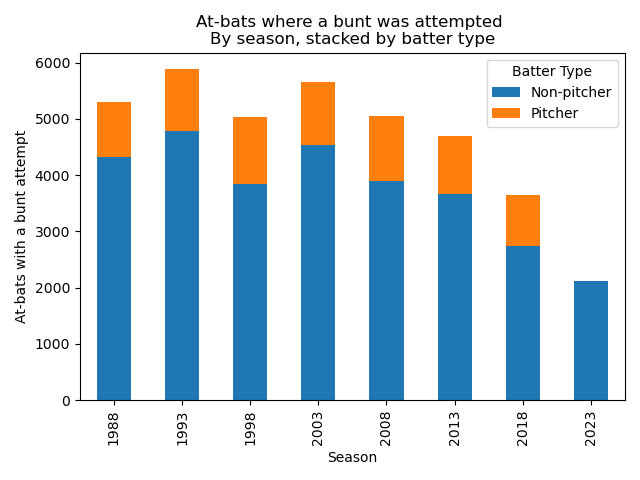

In [4]:
# BUNT ATTEMPTS
table1 = (plays_all.groupby(['Season', 'isbatterpitcher'])['bunt_attempted'].sum().unstack(fill_value=0))

table1.plot(kind = 'bar', stacked = True)
plt.xlabel('Season')
plt.ylabel('At-bats with a bunt attempt')
plt.title('At-bats where a bunt was attempted \nBy season, stacked by batter type')
plt.legend(title = 'Batter Type')
plt.tight_layout()

plt.savefig("Attempts_1988to2023.png", dpi = 300, bbox_inches = 'tight');

In [5]:
# BUNT TABLE

table2 = (plays_all.groupby(['Season', 'isbatterpitcher'])['bunt'].sum().unstack(fill_value = 0))
#table2

In [6]:
# BUNT EXECUTION

bunt_attempts = plays_all[(plays_all['bunt_attempted'] == 1) & (plays_all['isbatterpitcher'] == 'Non-pitcher')]

tables3 = (bunt_attempts.groupby(['Season', 'isbatterpitcher'])['bunt'].mean().unstack(fill_value = 0))
tables3 = tables3.reset_index()

tables3a = (bunt_attempts.groupby(['Season', 'isbatterpitcher', 'sacrifice_opportunity'])['bunt'].mean().unstack(fill_value = 0))
tables3a = tables3a.reset_index()

bunt = plays_all[(plays_all['bunt'] == 1) & (plays_all['isbatterpitcher'] == 'Non-pitcher')].copy()

tables3b = (bunt.groupby(['Season', 'isbatterpitcher', 'sacrifice_opportunity'])['positive_ab'].mean().unstack(fill_value = 0))
tables3b = tables3b.reset_index()

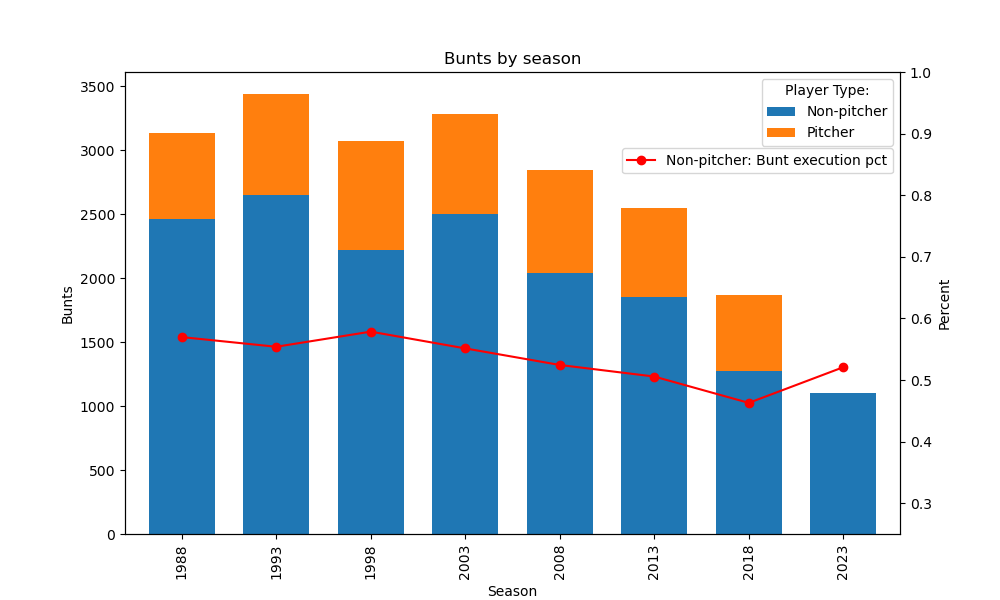

In [7]:
# PLOT BUNTS AND EXECUTION RATE

fig, ax1 = plt.subplots(figsize = (10,6))

table2.plot(kind = 'bar', stacked = True, ax = ax1, width = 0.7)
ax1.set_xlabel('Season')
ax1.set_ylabel('Bunts')
ax1.set_title('Bunts by season')
ax1.legend(title = 'Player Type:')

ax2 = ax1.twinx()
ax2.plot(tables3['Season'], tables3['Non-pitcher'], color = 'red', marker = 'o', label = 'Non-pitcher: Bunt execution pct')

ax2.set_ylabel('Percent')
ax2.set_ylim(0.25, 1)
ax2.legend(bbox_to_anchor = (1, 0.85));

plt.savefig("Bunts_1988to2023.png", dpi = 300, bbox_inches = 'tight');

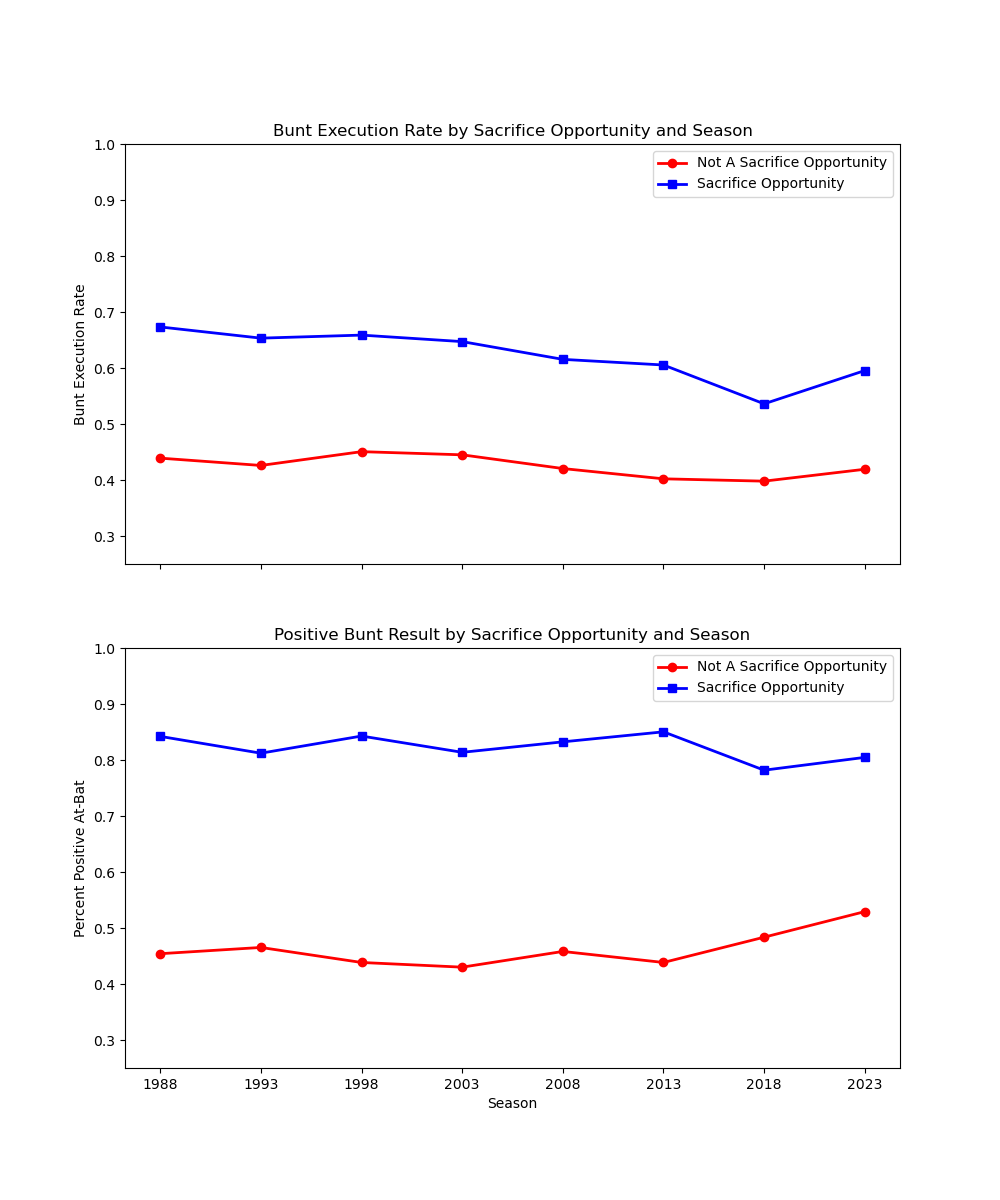

In [8]:
# BUNT EXECUTION AND POSITIVE EVENT RATES

fig, axes = plt.subplots(2, 1, figsize = (10, 12), sharex = True)  
axes[0].plot(tables3a['Season'], tables3a[0], marker = 'o', color = 'red', linewidth = 2, label = 'Not A Sacrifice Opportunity')
axes[0].plot(tables3a['Season'], tables3a[1], marker = 's', color = 'blue', linewidth = 2, label = 'Sacrifice Opportunity')
axes[0].set_ylabel('Bunt Execution Rate')
axes[0].set_title('Bunt Execution Rate by Sacrifice Opportunity and Season')
axes[0].set_ylim(0.25, 1)
axes[0].legend()

axes[1].plot(tables3b['Season'], tables3b[0], marker = 'o', color = 'red', linewidth = 2, label = 'Not A Sacrifice Opportunity')
axes[1].plot(tables3b['Season'], tables3b[1], marker = 's', color = 'blue', linewidth = 2, label = 'Sacrifice Opportunity')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Percent Positive At-Bat')
axes[1].set_title('Positive Bunt Result by Sacrifice Opportunity and Season')
axes[1].set_ylim(0.25, 1)
axes[1].legend();

plt.savefig("OppType_1988to2023.png", dpi = 300, bbox_inches =' tight');

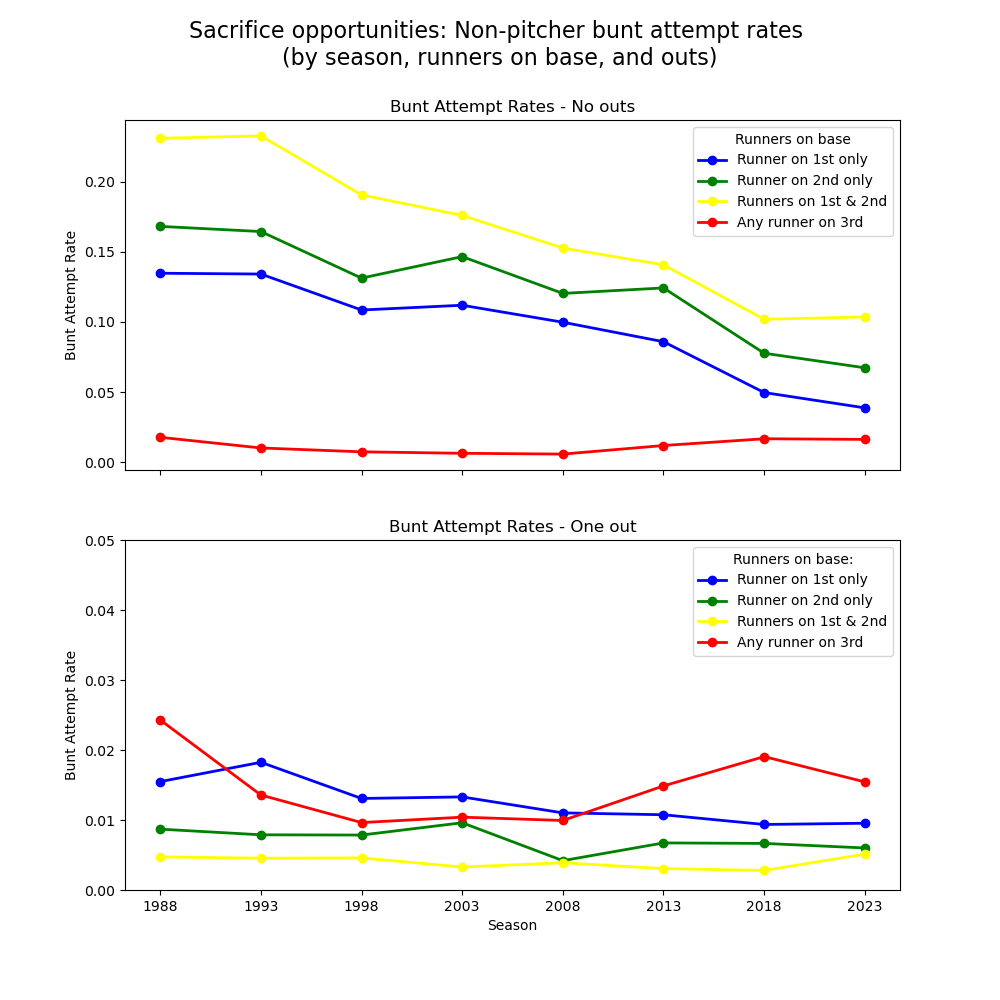

In [9]:
# SACRIFICE OPPORTUNITY RATES

sac_opp = plays_all[(plays_all['sacrifice_opportunity'] == 1) & (plays_all['isbatterpitcher'] == 'Non-pitcher')].copy()
sac_opp['runners_outs'] = sac_opp['runners_cat'].astype(str) + sac_opp['outs_pre'].astype(str)

table4 = (sac_opp.groupby(['runners_outs', 'Season', 'bunt_attempted']).size().unstack(fill_value=0))
table4['buntpct'] = table4[1] / (table4[0] + table4[1])
table4 = table4.reset_index()

table4_0 = table4[table4['runners_outs'].isin(['20', '30', '40', '50'])].copy()
table4_1 = table4[table4['runners_outs'].isin(['21', '31', '41', '51'])].copy()

table4_0_wide = table4_0.pivot(index = 'Season', columns = 'runners_outs', values = 'buntpct')
table4_0_wide.rename(columns = {'20': 'Runner on 1st only', '30': 'Runner on 2nd only', '40': 'Runners on 1st & 2nd',
                                '50': 'Any runner on 3rd'}, inplace = True)

table4_1_wide = table4_1.pivot(index = 'Season', columns = 'runners_outs', values = 'buntpct')
table4_1_wide.rename(columns = {'21': 'Runner on 1st only', '31': 'Runner on 2nd only', '41': 'Runners on 1st & 2nd', 
                                '51': 'Any runner on 3rd'}, inplace = True)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize = (10,10), sharex = True)

colors0 = ['blue', 'green', 'yellow', 'red'] 
table4_0_wide.plot(marker = 'o', linewidth = 2, ax = ax0, color = colors0)
ax0.legend(title = 'Runners on base')
ax0.set_ylabel('Bunt Attempt Rate')
ax0.set_title('Bunt Attempt Rates - No outs')

colors1 = ['blue', 'green', 'yellow', 'red']
table4_1_wide.plot(marker = 'o', linewidth = 2, ax = ax1, color = colors1)
ax1.legend(title = 'Runners on base:')
ax1.set_xlabel('Season')
ax1.set_ylabel('Bunt Attempt Rate')
ax1.set_ylim(0, .05)
ax1.set_title('Bunt Attempt Rates - One out')

fig.suptitle('Sacrifice opportunities: Non-pitcher bunt attempt rates \n(by season, runners on base, and outs)', fontsize = 16);

plt.savefig("Rates_1988to2023.png", dpi = 300, bbox_inches = 'tight');

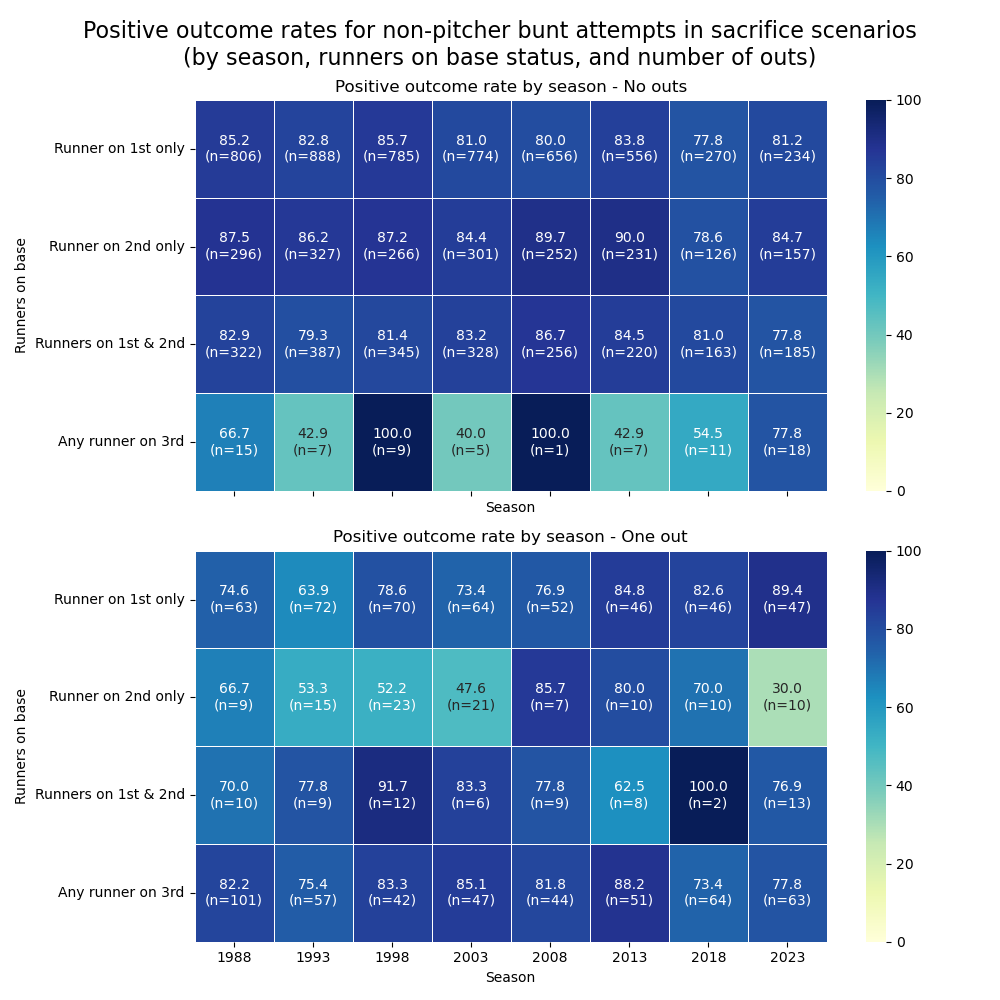

In [10]:
# SACRIFICE HEATMAP

bunt['runners_outs'] = bunt['runners_cat'].astype(str) + bunt['outs_pre'].astype(str)

# Create table of counts
table5_counts = bunt.groupby(['runners_outs', 'Season', 'positive_ab']).size().unstack(fill_value = 0)
table5_counts['positive_rate'] = 100 * table5_counts[1] / (table5_counts[0] + table5_counts[1])
table5_counts = table5_counts.reset_index()

# Split by outs and runners
table5_0 = table5_counts[table5_counts['runners_outs'].isin(['20','30','40','50'])].copy()
table5_1 = table5_counts[table5_counts['runners_outs'].isin(['21','31','41','51'])].copy()

# Pivot to wide format for heatmap
table5_0_wide = table5_0.pivot(index = 'Season', columns = 'runners_outs', values = 'positive_rate')
table5_0_wide.rename(columns = {'20':'Runner on 1st only','30':'Runner on 2nd only',
                                '40':'Runners on 1st & 2nd','50':'Any runner on 3rd'}, inplace = True)

table5_1_wide = table5_1.pivot(index = 'Season', columns = 'runners_outs', values = 'positive_rate')
table5_1_wide.rename(columns = {'21':'Runner on 1st only','31':'Runner on 2nd only',
                                '41':'Runners on 1st & 2nd','51':'Any runner on 3rd'}, inplace = True)

# Get counts aligned with rate columns
table5_0_n = bunt[bunt['outs_pre']==0].groupby(['Season','runners_outs']).size().reset_index(name='count')
table5_1_n = bunt[bunt['outs_pre']==1].groupby(['Season','runners_outs']).size().reset_index(name='count')

# Pivot counts to match heatmap
table5_0_n_wide = table5_0_n.pivot(index = 'Season', columns = 'runners_outs', values = 'count').reindex(columns = ['20','30','40','50'], fill_value = 0)
table5_0_n_wide.rename(columns={'20':'Runner on 1st only','30':'Runner on 2nd only',
                                '40':'Runners on 1st & 2nd','50':'Any runner on 3rd'}, inplace=True)

table5_1_n_wide = table5_1_n.pivot(inde = 'Season', columns = 'runners_outs', values = 'count').reindex(columns = ['21','31','41','51'], fill_value = 0)
table5_1_n_wide.rename(columns = {'21':'Runner on 1st only','31':'Runner on 2nd only',
                                '41':'Runners on 1st & 2nd','51':'Any runner on 3rd'}, inplace = True)

# Transpose for heatmap orientation
rate0 = table5_0_wide.T.astype(float)
rate1 = table5_1_wide.T.astype(float)
n0 = table5_0_n_wide.T.astype(int)
n1 = table5_1_n_wide.T.astype(int)

# Build annotation labels
labels0 = np.char.add(rate0.round(1).astype(str).values, ("\n(n=" + n0.astype(str).values + ")"))
labels1 = np.char.add(rate1.round(1).astype(str).values, ("\n(n=" + n1.astype(str).values + ")"))

# Plot heatmaps
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10,10), sharex=True)

sns.heatmap(rate0, annot = labels0, fmt = "", cmap = "YlGnBu", vmin = 0, vmax = 100, linewidths = 0.5, ax = ax0)
ax0.set_ylabel("Runners on base")
ax0.set_title("Positive outcome rate by season - No outs")

sns.heatmap(rate1, annot = labels1, fmt = "", cmap = "YlGnBu", vmin = 0, vmax = 100, linewidths = 0.5, ax = ax1)
ax1.set_ylabel("Runners on base")
ax1.set_xlabel("Season")
ax1.set_title("Positive outcome rate by season - One out")

fig.suptitle("Positive outcome rates for non-pitcher bunt attempts in sacrifice scenarios\n(by season, runners on base status, and number of outs)", fontsize=16)

plt.tight_layout()
plt.show();

plt.savefig("Outcome_1988to2023.png", dpi = 300, bbox_inches = 'tight');